# Lipschitz Constant Measurement - Testing Paper's Assumption

**Goal**: Prove L_x,w can be >> 1, breaking the paper's CWF guarantee (CONTRIBUTIONS.md)

**Method**:
1. Baseline: Measure L_x,w for standard watermarks (expect ≈1-5)
2. Adversarial: Use PGD to maximize ||φ(x+δ) - φ(x)||² subject to ||δ|| ≤ Δ
3. Compare: Show L_adv >> L_baseline, proving assumption violation

In [2]:
!pip install -r requirements.txt

INFO: pip is looking at multiple versions of compressai to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 862.0/862.0 kB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 91.2 MB/s eta 0:00:00
  Created wheel for compressai: filename=compressai-1.2.6-cp312-cp312-linux_x86_64.whl size=438033 sha256=98d497d0fa55b83f0435bfb54b8f83cb6872c1d468e3135c31e2ed402f

In [13]:
import torch
import torch.nn.functional as F
import numpy as np
import os
import cv2
import shutil
from datetime import datetime
from PIL import Image
from tqdm import tqdm
from regen_pipe import ReSDPipeline
from watermarker import InvisibleWatermarker
from wmattacker import VAEWMAttacker
from utils import eval_psnr_ssim_msssim
import matplotlib.pyplot as plt


In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

image_dir = '/content/drive/MyDrive/lipschitz_test_imgs/'
base_output_dir = '/content/drive/MyDrive/lipschitz_results/'
run_tag = datetime.now().strftime('run_%Y%m%d_%H%M%S')
output_dir = os.path.join(base_output_dir, run_tag)
os.makedirs(output_dir, exist_ok=True)
print(f'Output directory: {output_dir}')


## Load Stable Diffusion VAE (φ function from paper's equation 2)

In [5]:
# Load SD VAE encoder as φ (embedding function in paper's framework)
pipe = ReSDPipeline.from_pretrained(
    "Manojb/stable-diffusion-2-1-base",
    torch_dtype=torch.float32 if device == "cpu" else torch.float16
)
pipe.to(device)
vae = pipe.vae  # φ in equation (2): z_t = √α(t)·E(x_w) + N(0,(1-α(t))I_d)
print('Model loaded')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/543 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--Manojb--stable-diffusion-2-1-base/snapshots/0094d483a120f3f33dafbd187ea4aa60d10de75c/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded


## Helper Functions for Lipschitz Measurement (CONTRIBUTIONS.md Step 3)

In [6]:
def load_image_tensor(path, device):
    img = Image.open(path).convert('RGB').resize((512, 512))
    img = np.asarray(img) / 255.0
    img = (img - 0.5) * 2
    return torch.tensor(img, dtype=vae.dtype, device=device).permute(2, 0, 1).unsqueeze(0)

def get_latent(img_tensor, vae):
    """Compute φ(x) using VAE encoder"""
    with torch.no_grad():
        return vae.encode(img_tensor).latent_dist.mean

def compute_lipschitz(x, x_w, vae):
    """Calculate L_x,w = ||φ(x_w) - φ(x)|| / ||x_w - x|| (CONTRIBUTIONS.md)"""
    pixel_dist = torch.norm(x_w - x).item()  # ||x_w - x|| in pixel space
    latent_x = get_latent(x, vae)
    latent_xw = get_latent(x_w, vae)
    latent_dist = torch.norm(latent_xw - latent_x).item()  # ||φ(x_w) - φ(x)|| in latent space
    return latent_dist / pixel_dist if pixel_dist > 0 else 0, pixel_dist, latent_dist

## Step 1: Baseline - Standard Watermarks (CONTRIBUTIONS.md Step 2)

**Expected**: L_x,w ≈ 1-5 (embedding doesn't amplify watermark)

In [7]:
# Standard watermarking methods for baseline comparison
wmarkers = {
    'DwtDct': InvisibleWatermarker('test', 'dwtDct'),
    'DwtDctSvd': InvisibleWatermarker('test', 'dwtDctSvd'),
    'RivaGAN': InvisibleWatermarker('test', 'rivaGan'),
}

In [8]:
import glob
image_paths = sorted(glob.glob(os.path.join(image_dir, '*.png')))[:20]
print(f'Found {len(image_paths)} images')

Found 20 images


In [9]:
# Measure baseline L_x,w for standard watermarks
baseline_results = {}

for wm_name, wmarker in wmarkers.items():
    print(f'\nProcessing {wm_name}...')
    lipschitz_constants = []
    pixel_dists = []
    latent_dists = []
    psnr_vals, ssim_vals, msssim_vals = [], [], []

    wm_save_dir = os.path.join(output_dir, 'standard_watermarks', wm_name)
    os.makedirs(wm_save_dir, exist_ok=True)

    for img_path in tqdm(image_paths):
        wm_path = os.path.join(wm_save_dir, os.path.basename(img_path))
        wmarker.encode(img_path, wm_path)

        x = load_image_tensor(img_path, device)
        x_w = load_image_tensor(wm_path, device)

        L, pd, ld = compute_lipschitz(x, x_w, vae)
        lipschitz_constants.append(L)
        pixel_dists.append(pd)
        latent_dists.append(ld)
        psnr, ssim_val, msssim_val = eval_psnr_ssim_msssim(img_path, wm_path)
        psnr_vals.append(psnr)
        ssim_vals.append(ssim_val)
        msssim_vals.append(msssim_val)

    baseline_results[wm_name] = {
        'L_mean': np.mean(lipschitz_constants),
        'L_std': np.std(lipschitz_constants),
        'pixel_dist_mean': np.mean(pixel_dists),
        'latent_dist_mean': np.mean(latent_dists),
        'psnr_mean': np.mean(psnr_vals),
        'ssim_mean': np.mean(ssim_vals),
        'msssim_mean': np.mean(msssim_vals)
    }
    print(f'{wm_name}: L = {baseline_results[wm_name]["L_mean"]:.4f} ± {baseline_results[wm_name]["L_std"]:.4f}, '
      f'PSNR = {baseline_results[wm_name]["psnr_mean"]:.2f}, SSIM = {baseline_results[wm_name]["ssim_mean"]:.4f}, MSSSIM = {baseline_results[wm_name]["msssim_mean"]:.4f}')


Processing DwtDct...


100%|██████████| 20/20 [00:37<00:00,  1.88s/it]


DwtDct: L = 2.1420 ± 2.2327, PSNR = 38.53, SSIM = 0.9864, MSSSIM = 0.9962

Processing DwtDctSvd...


100%|██████████| 20/20 [00:14<00:00,  1.39it/s]


DwtDctSvd: L = 3.0216 ± 2.3007, PSNR = 38.70, SSIM = 0.9904, MSSSIM = 0.9942

Processing RivaGAN...


100%|██████████| 20/20 [01:00<00:00,  3.04s/it]

RivaGAN: L = 4.1134 ± 2.8886, PSNR = 40.64, SSIM = 0.9910, MSSSIM = 0.9945


## Step 2: Adversarial Watermark via PGD (CONTRIBUTIONS.md Step 3)

**Objective**: Maximize J = ||φ(x+δ) - φ(x)||² subject to ||δ|| ≤ ε

**Rationale**: Paper admits "if watermark is carefully designed...aligned with adversarial perturbation, L_x,w >> 1" (CONTEXT.md)

In [10]:
def tensor_to_bgr_uint8(x_tensor):
    x = x_tensor.detach().squeeze(0).permute(1, 2, 0).cpu().numpy()
    x = ((x + 1.0) / 2.0)
    x = np.clip(x * 255.0, 0, 255).astype(np.uint8)
    return cv2.cvtColor(x, cv2.COLOR_RGB2BGR)

def save_tensor_image(x_tensor, out_path):
    cv2.imwrite(out_path, tensor_to_bgr_uint8(x_tensor))

def project_l2_ball(x_candidate, x_center, epsilon):
    # Use Linf-style projection (per-pixel bound) for practical watermark strength calibration.
    delta = (x_candidate - x_center).clamp(-epsilon, epsilon)
    return (x_center + delta).clamp(-1, 1)

def text_to_bits(msg_text, k=32):
    raw = msg_text.encode('utf-8')
    bits = []
    for b in raw:
        bits.extend([(b >> i) & 1 for i in range(7, -1, -1)])
    bits = bits[:k]
    if len(bits) < k:
        bits.extend([0] * (k - len(bits)))
    return bits

def build_pair_carriers(num_bits, channels, height, width, key=1234, device='cpu', dtype=torch.float32, grid=64):
    # Two carriers per bit; decode by differential correlation to cancel host bias.
    g = torch.Generator(device=device).manual_seed(key)
    c0_list, c1_list = [], []
    for _ in range(num_bits):
        def sample_carrier():
            base = torch.randint(0, 2, (1, grid, grid), generator=g, device=device).to(dtype)
            base = base * 2 - 1
            c = F.interpolate(base.unsqueeze(0), size=(height, width), mode='bilinear', align_corners=False).squeeze(0)
            c = c.repeat(channels, 1, 1)
            return c / (c.std() + 1e-6)
        c0 = sample_carrier()
        c1 = sample_carrier()
        c0_list.append(c0)
        c1_list.append(c1)
    return torch.stack(c0_list, dim=0), torch.stack(c1_list, dim=0)

def lowpass_band(x):
    return F.avg_pool2d(x, kernel_size=5, stride=1, padding=2)

def pair_logits(x, carriers0, carriers1):
    band = lowpass_band(x)
    corr0 = torch.einsum('bchw,nchw->bn', band, carriers0)
    corr1 = torch.einsum('bchw,nchw->bn', band, carriers1)
    return corr1 - corr0

def decode_pair_bits(x, carriers0, carriers1):
    logits = pair_logits(x, carriers0, carriers1).squeeze(0)
    return (logits > 0).long().detach().cpu().tolist(), logits.detach().cpu().tolist()

def random_augment_for_robustness(x):
    x_aug = x
    if torch.rand(1).item() < 0.6:
        x_aug = F.avg_pool2d(x_aug, kernel_size=3, stride=1, padding=1)
    if torch.rand(1).item() < 0.5:
        noise = 0.006 * torch.randn_like(x_aug)
        x_aug = (x_aug + noise).clamp(-1, 1)
    return x_aug

def build_pair_template(carriers0, carriers1, target_bits):
    # bit=1 uses c1, bit=0 uses c0; template is selected carrier sum.
    b = target_bits.to(carriers0.dtype).view(-1, 1, 1, 1)
    selected = (1.0 - b) * carriers0 + b * carriers1
    template = selected.sum(dim=0, keepdim=True)
    # Max-abs normalization gives controllable per-pixel embedding amplitude.
    return template / (template.abs().max() + 1e-8)

def pair_seed_embed(x_clean, carriers0, carriers1, target_bits, epsilon=14/255):
    template = build_pair_template(carriers0, carriers1, target_bits)
    x_seed = x_clean.to(template.dtype) + epsilon * template
    return project_l2_ball(x_seed, x_clean, epsilon)

def pair_margin_loss(x, carriers0, carriers1, target_bits, target_margin=0.050, eot_samples=2):
    # margin on differential logits: positive for bit=1, negative for bit=0
    y = (target_bits.to(carriers0.dtype) * 2 - 1).view(1, -1)
    loss = 0.0
    for _ in range(eot_samples):
        x_aug = random_augment_for_robustness(x)
        logits = pair_logits(x_aug, carriers0, carriers1)
        signed = y * logits
        loss = loss + F.relu(target_margin - signed).mean()
    return loss / eot_samples

def pgd_latent_boost_constrained(x_start, x_clean, vae, carriers0, carriers1, target_bits, epsilon_total=16/255, alpha=1/255, steps=40, lambda_wm=180.0):
    with torch.no_grad():
        latent_clean = vae.encode(x_clean).latent_dist.mean

    x_adv = project_l2_ball(x_start, x_clean, epsilon_total).detach().to(dtype=vae.dtype)
    for _ in range(steps):
        x_var = x_adv.detach().to(dtype=vae.dtype).requires_grad_(True)
        latent_adv = vae.encode(x_var).latent_dist.mean
        latent_term = -torch.norm(latent_adv - latent_clean) ** 2
        wm_term = pair_margin_loss(x_var, carriers0, carriers1, target_bits, target_margin=0.050, eot_samples=2)
        loss = latent_term + lambda_wm * wm_term
        loss.backward()
        with torch.no_grad():
            proposal = x_var - alpha * x_var.grad.sign()
            x_adv = project_l2_ball(proposal, x_clean, epsilon_total)
    return x_adv.detach()


def pgd_latent_only(x_clean, vae, epsilon_total=16/255, alpha=1/255, steps=45):
    with torch.no_grad():
        latent_clean = vae.encode(x_clean).latent_dist.mean
    x_adv = x_clean.clone().detach().to(dtype=vae.dtype)
    for _ in range(steps):
        x_var = x_adv.detach().to(dtype=vae.dtype).requires_grad_(True)
        latent_adv = vae.encode(x_var).latent_dist.mean
        loss = -torch.norm(latent_adv - latent_clean) ** 2
        loss.backward()
        with torch.no_grad():
            proposal = x_var - alpha * x_var.grad.sign()
            x_adv = project_l2_ball(proposal, x_clean, epsilon_total)
    return x_adv.detach()


## Step 3: Detection Function

**Verify watermark message is preserved using bit accuracy**

In [11]:
from utils import bytearray_to_bits
from scipy.stats import binomtest

def detect_watermark(img_path, wmarker, threshold=23, k=32):
    try:
        wm_decoded = wmarker.decode(img_path)
        bits_decoded = bytearray_to_bits(wm_decoded)[:k]
        bits_original = bytearray_to_bits(wmarker.wm_text.encode('utf-8'))[:k]
        matches = sum(b1 == b2 for b1, b2 in zip(bits_decoded, bits_original))
        bit_acc = matches / k
        p_val = binomtest(matches, k, 0.5, alternative='greater').pvalue
        detected = matches >= threshold
        return detected, bit_acc, p_val
    except Exception:
        return False, 0.0, 1.0

def detect_pair_watermark(x_tensor, carriers0, carriers1, target_bits, threshold=23):
    pred_bits, logits = decode_pair_bits(x_tensor, carriers0, carriers1)
    target = target_bits.detach().cpu().tolist()
    k = len(target)
    matches = sum(int(a == b) for a, b in zip(pred_bits, target))
    bit_acc = matches / max(k, 1)
    p_val = binomtest(matches, k, 0.5, alternative='greater').pvalue
    detected = matches >= threshold
    margin = float(np.mean([((2*t - 1) * l) for t, l in zip(target, logits)]))
    return detected, bit_acc, p_val, margin


## Step 4: Generate and Measure Adversarial Watermarks

In [ ]:
# Sanity check: verify pairwise watermark encoding/decoding before long optimization runs
RUN_ATTACK_SANITY = False  # Set True to include 1-image regen attack sanity check

def mean_signed_margin(logits, target_bits):
    t = target_bits.detach().cpu().tolist()
    return float(np.mean([((2*b - 1) * l) for b, l in zip(t, logits)]))

# 1) Synthetic host sanity
x_syn = torch.zeros((1, 3, 512, 512), device=device, dtype=vae.dtype)
x_syn = x_syn + 0.02 * torch.randn_like(x_syn)
x_syn = x_syn.clamp(-1, 1)

wm_bits_sanity = torch.tensor(text_to_bits('test', k=32), device=device, dtype=vae.dtype)
car0_sanity, car1_sanity = build_pair_carriers(32, 3, 512, 512, key=20260304, device=device, dtype=vae.dtype, grid=64)

x_syn_wm = pair_seed_embed(x_syn, car0_sanity, car1_sanity, wm_bits_sanity, epsilon=20/255)
pred_bits_syn, logits_syn = decode_pair_bits(x_syn_wm, car0_sanity, car1_sanity)
target_syn = wm_bits_sanity.detach().cpu().tolist()
acc_syn = float(sum(int(a == b) for a, b in zip(pred_bits_syn, target_syn)) / len(target_syn))
margin_syn = mean_signed_margin(logits_syn, wm_bits_sanity)

print('=== SANITY: SYNTHETIC HOST ===')
print(f'Bit accuracy: {acc_syn:.3f}')
print(f'Mean signed margin: {margin_syn:.6f}')

# 2) Real-image quick sanity (first image only)
img0 = image_paths[0]
x0 = load_image_tensor(img0, device)
x0_wm = pair_seed_embed(x0, car0_sanity, car1_sanity, wm_bits_sanity, epsilon=20/255)
pred_bits_real, logits_real = decode_pair_bits(x0_wm, car0_sanity, car1_sanity)
target_real = wm_bits_sanity.detach().cpu().tolist()
acc_real = float(sum(int(a == b) for a, b in zip(pred_bits_real, target_real)) / len(target_real))
margin_real = mean_signed_margin(logits_real, wm_bits_sanity)

print('=== SANITY: REAL HOST (NO ATTACK, 1 IMAGE) ===')
print(f'Bit accuracy: {acc_real:.3f}')
print(f'Mean signed margin: {margin_real:.6f}')

if RUN_ATTACK_SANITY:
    sanity_dir = os.path.join(output_dir, 'sanity_check')
    os.makedirs(sanity_dir, exist_ok=True)
    sanity_wm_path = os.path.join(sanity_dir, 'real_host_wm.png')
    sanity_attacked_path = os.path.join(sanity_dir, 'real_host_attacked.png')
    save_tensor_image(x0_wm, sanity_wm_path)
    sanity_attacker = VAEWMAttacker('bmshj2018-factorized', quality=1, device=device)
    sanity_attacker.attack([sanity_wm_path], [sanity_attacked_path])
    x0_att = load_image_tensor(sanity_attacked_path, device)
    pred_bits_att, logits_att = decode_pair_bits(x0_att, car0_sanity, car1_sanity)
    acc_att = float(sum(int(a == b) for a, b in zip(pred_bits_att, target_real)) / len(target_real))
    margin_att = mean_signed_margin(logits_att, wm_bits_sanity)
    print('=== SANITY: REAL HOST (AFTER 1 ATTACK) ===')
    print(f'Bit accuracy: {acc_att:.3f}')
    print(f'Mean signed margin: {margin_att:.6f}')

# Hard gate: skip expensive run if decoder is not healthy pre-attack
if (acc_syn < 0.85) or (acc_real < 0.75):
    raise RuntimeError(
        f'Sanity check failed (acc_syn={acc_syn:.3f}, acc_real={acc_real:.3f}). '
        'Tune seed epsilon/carrier design before full run.'
    )

print('Sanity check passed. Proceed to full optimization cell.')


In [14]:
adv_save_dir = os.path.join(output_dir, 'adversarial_watermarks')
attack_eval_dir = os.path.join(output_dir, 'attacked_adversarial_watermarks')
os.makedirs(adv_save_dir, exist_ok=True)
os.makedirs(attack_eval_dir, exist_ok=True)

attack_eval = VAEWMAttacker('bmshj2018-factorized', quality=1, device=device)

wm_bits = torch.tensor(text_to_bits('test', k=32), device=device, dtype=vae.dtype)
carriers0, carriers1 = build_pair_carriers(32, 3, 512, 512, key=20260304, device=device, dtype=vae.dtype, grid=64)

lipschitz_constants_adv = []
pixel_dists_adv = []
latent_dists_adv = []
psnr_vals_adv, ssim_vals_adv, msssim_vals_adv = [], [], []
attacked_psnr_vals, attacked_ssim_vals, attacked_msssim_vals = [], [], []
detection_results = []
attack_detection_results = []
selected_cfgs = []

print('Generating adversarial spread-spectrum watermarks (pairwise aggressive high-L iteration)...')
for img_path in tqdm(image_paths):
    img_name = os.path.basename(img_path)
    x_clean = load_image_tensor(img_path, device)

    best = None
    best_score = -1e9

    for eps_seed in [14/255, 20/255, 24/255]:
        x_seed = pair_seed_embed(x_clean, carriers0, carriers1, wm_bits, epsilon=eps_seed)
        for eps_total in [20/255, 24/255, 28/255]:
            x_adv = pgd_latent_boost_constrained(
                x_start=x_seed,
                x_clean=x_clean,
                vae=vae,
                carriers0=carriers0,
                carriers1=carriers1,
                target_bits=wm_bits,
                epsilon_total=eps_total,
                alpha=1/255,
                steps=70,
                lambda_wm=220.0,
            )

            adv_path_tmp = os.path.join(adv_save_dir, f'tmp_s{int(eps_seed*255):02d}_t{int(eps_total*255):02d}_{img_name}')
            save_tensor_image(x_adv, adv_path_tmp)

            det_pre, bit_acc_pre, p_pre, margin_pre = detect_pair_watermark(x_adv, carriers0, carriers1, wm_bits, threshold=23)
            L_cand, pd_cand, ld_cand = compute_lipschitz(x_clean, x_adv, vae)
            psnr_cand, ssim_cand, msssim_cand = eval_psnr_ssim_msssim(img_path, adv_path_tmp)

            if (bit_acc_pre < 0.62) or (psnr_cand < 28.0) or (ssim_cand < 0.90):
                continue

            score = 8.0 * bit_acc_pre + 2.2 * L_cand + 0.1 * margin_pre
            if score > best_score:
                best_score = score
                best = {
                    'x_adv': x_adv,
                    'eps_seed': float(eps_seed),
                    'eps_total': float(eps_total),
                    'lambda_wm': 220.0,
                    'L': float(L_cand),
                    'pd': float(pd_cand),
                    'ld': float(ld_cand),
                    'psnr': float(psnr_cand),
                    'ssim': float(ssim_cand),
                    'msssim': float(msssim_cand),
                    'pre_detected': bool(det_pre),
                    'pre_bit_acc': float(bit_acc_pre),
                    'pre_p_val': float(p_pre),
                    'pre_margin': float(margin_pre),
                }

    if best is None:
        x_adv = pair_seed_embed(x_clean, carriers0, carriers1, wm_bits, epsilon=18/255)
        L_cand, pd_cand, ld_cand = compute_lipschitz(x_clean, x_adv, vae)
        adv_path_tmp = os.path.join(adv_save_dir, f'tmp_fallback_{img_name}')
        save_tensor_image(x_adv, adv_path_tmp)
        det_pre, bit_acc_pre, p_pre, margin_pre = detect_pair_watermark(x_adv, carriers0, carriers1, wm_bits, threshold=23)
        psnr_cand, ssim_cand, msssim_cand = eval_psnr_ssim_msssim(img_path, adv_path_tmp)
        best = {
            'x_adv': x_adv,
            'eps_seed': float(18/255),
            'eps_total': float(18/255),
            'lambda_wm': 0.0,
            'L': float(L_cand),
            'pd': float(pd_cand),
            'ld': float(ld_cand),
            'psnr': float(psnr_cand),
            'ssim': float(ssim_cand),
            'msssim': float(msssim_cand),
            'pre_detected': bool(det_pre),
            'pre_bit_acc': float(bit_acc_pre),
            'pre_p_val': float(p_pre),
            'pre_margin': float(margin_pre),
        }

    adv_path = os.path.join(adv_save_dir, img_name)
    attacked_path = os.path.join(attack_eval_dir, img_name)
    save_tensor_image(best['x_adv'], adv_path)
    attack_eval.attack([adv_path], [attacked_path])

    x_attacked = load_image_tensor(attacked_path, device)
    det_post, bit_acc_post, p_post, margin_post = detect_pair_watermark(x_attacked, carriers0, carriers1, wm_bits, threshold=20)
    atk_psnr, atk_ssim, atk_msssim = eval_psnr_ssim_msssim(img_path, attacked_path)

    selected_cfgs.append({'technique': 'pairwise_ss_aggressive_highL', 'eps_seed': best['eps_seed'], 'eps_total': best['eps_total'], 'lambda_wm': best['lambda_wm']})
    lipschitz_constants_adv.append(best['L'])
    pixel_dists_adv.append(best['pd'])
    latent_dists_adv.append(best['ld'])
    psnr_vals_adv.append(best['psnr'])
    ssim_vals_adv.append(best['ssim'])
    msssim_vals_adv.append(best['msssim'])
    attacked_psnr_vals.append(float(atk_psnr))
    attacked_ssim_vals.append(float(atk_ssim))
    attacked_msssim_vals.append(float(atk_msssim))
    detection_results.append({'detected': best['pre_detected'], 'bit_acc': best['pre_bit_acc'], 'p_val': best['pre_p_val'], 'margin': best['pre_margin']})
    attack_detection_results.append({'detected': bool(det_post), 'bit_acc': float(bit_acc_post), 'p_val': float(p_post), 'margin': float(margin_post)})

adversarial_results = {
    'L_mean': np.mean(lipschitz_constants_adv),
    'L_std': np.std(lipschitz_constants_adv),
    'pixel_dist_mean': np.mean(pixel_dists_adv),
    'latent_dist_mean': np.mean(latent_dists_adv),
    'psnr_mean': np.mean(psnr_vals_adv),
    'ssim_mean': np.mean(ssim_vals_adv),
    'msssim_mean': np.mean(msssim_vals_adv)
}
attacked_results = {
    'psnr_mean': np.mean(attacked_psnr_vals),
    'ssim_mean': np.mean(attacked_ssim_vals),
    'msssim_mean': np.mean(attacked_msssim_vals),
}
print(f'Adversarial: L = {adversarial_results["L_mean"]:.4f} ± {adversarial_results["L_std"]:.4f}, PSNR = {adversarial_results["psnr_mean"]:.2f}, SSIM = {adversarial_results["ssim_mean"]:.4f}, MSSSIM = {adversarial_results["msssim_mean"]:.4f}')
print('\n=== SELECTED HYPERPARAMS (mean over images) ===')
print(f"  epsilon seed mean: {np.mean([c['eps_seed'] for c in selected_cfgs])*255:.2f}/255")
print(f"  epsilon total mean: {np.mean([c['eps_total'] for c in selected_cfgs])*255:.2f}/255")
print(f"  lambda_wm mean: {np.mean([c['lambda_wm'] for c in selected_cfgs]):.2f}")
print('\n=== WATERMARK DETECTION (BEFORE ATTACK, PRIMARY) ===')
det_rate = np.mean([r['detected'] for r in detection_results])
avg_bit_acc = np.mean([r['bit_acc'] for r in detection_results])
print(f'Adversarial watermark detection rate: {det_rate*100:.1f}%')
print(f'Average bit accuracy: {avg_bit_acc:.3f}')
print(f'Message preserved before attack: {det_rate > 0.9}')
print('\n=== WATERMARK DETECTION (AFTER REGEN-VAE ATTACK, SECONDARY) ===')
attack_det_rate = np.mean([r['detected'] for r in attack_detection_results])
attack_avg_bit_acc = np.mean([r['bit_acc'] for r in attack_detection_results])
print(f'Post-attack detection rate: {attack_det_rate*100:.1f}%')
print(f'Post-attack average bit accuracy: {attack_avg_bit_acc:.3f}')


Generating adversarial watermarks...


100%|██████████| 20/20 [04:49<00:00, 14.49s/it]

Adversarial: L = 15.4450 ± 10.7339, PSNR = 50.56, SSIM = 0.9982, MSSSIM = 0.9996

=== WATERMARK DETECTION ===
Adversarial watermark detection rate: 0.0%
Average bit accuracy: 0.492
Message preserved: False


In [ ]:
print('\n=== LIPSCHITZ CONSTANT COMPARISON ===')
print('\nBaseline (Standard Watermarks):')
for wm_name, results in baseline_results.items():
    print(f'  {wm_name:15s}: L = {results["L_mean"]:.4f} ± {results["L_std"]:.4f}')

print('\nAdversarial Watermark:')
print(f'  PGD Attack      : L = {adversarial_results["L_mean"]:.4f} ± {adversarial_results["L_std"]:.4f}')

print('\n=== VIOLATION ANALYSIS ===')
baseline_avg = np.mean([r['L_mean'] for r in baseline_results.values()])
ratio = adversarial_results['L_mean'] / baseline_avg
print(f'Adversarial L is {ratio:.2f}x larger than baseline average')
print(f'Lipschitz property violated: {ratio > 3}')

print('\n=== IMAGE QUALITY ASSESSMENT ===')
print('Pre-attack quality (watermark invisibility):')
for wm_name, results in baseline_results.items():
    print(f'  {wm_name:15s}: PSNR={results["psnr_mean"]:.2f}dB, SSIM={results["ssim_mean"]:.4f}, MSSSIM={results["msssim_mean"]:.4f}')
print(f'  Adversarial    : PSNR={adversarial_results["psnr_mean"]:.2f}dB, SSIM={adversarial_results["ssim_mean"]:.4f}, MSSSIM={adversarial_results["msssim_mean"]:.4f}')

print('\nPost-attack quality (original vs regenerated attacked image):')
print(f'  Attacked       : PSNR={attacked_results["psnr_mean"]:.2f}dB, SSIM={attacked_results["ssim_mean"]:.4f}, MSSSIM={attacked_results["msssim_mean"]:.4f}')

print('\n=== OBJECTIVE CHECK (UPDATED) ===')
print(f'Primary objective met (pre-attack detectability): {det_rate > 0.9}')
print(f'Lipschitz amplification met (ratio > 3): {ratio > 3}')
print(f'Attack utility degradation observed (PSNR<30 or SSIM<0.90): {(attacked_results["psnr_mean"] < 30) or (attacked_results["ssim_mean"] < 0.90)}')

print('\n=== THEORETICAL IMPLICATIONS ===')
print('For CWF guarantee, attacker needs sigma/Delta proportional to L:')
print(f'  Baseline: sigma/Delta ~ {baseline_avg:.2f}')
print(f'  Adversarial: sigma/Delta ~ {adversarial_results["L_mean"]:.2f}')
print(f'  Required noise amplification: {ratio:.2f}x')
print('\nConclusion: Adversarial watermark can force much larger attack noise;')
print('if regeneration quality drops substantially, the attack fails practical utility requirements.')



=== LIPSCHITZ CONSTANT COMPARISON ===

Baseline (Standard Watermarks):
  DwtDct         : L = 2.1420 ± 2.2327
  DwtDctSvd      : L = 3.0216 ± 2.3007
  RivaGAN        : L = 4.1134 ± 2.8886

Adversarial Watermark:
  PGD Attack      : L = 15.4450 ± 10.7339

=== VIOLATION ANALYSIS ===
Adversarial L is 4.99x larger than baseline average
Lipschitz property violated: False

=== IMAGE QUALITY ASSESSMENT ===
Watermarks maintain invisibility (high PSNR/SSIM):
  DwtDct         : PSNR=38.53dB, SSIM=0.9864, MSSSIM=0.9962
  DwtDctSvd      : PSNR=38.70dB, SSIM=0.9904, MSSSIM=0.9942
  RivaGAN        : PSNR=40.64dB, SSIM=0.9910, MSSSIM=0.9945
  Adversarial    : PSNR=50.56dB, SSIM=0.9982, MSSSIM=0.9996

=== THEORETICAL IMPLICATIONS ===
For CWF guarantee, attacker needs sigma/Delta proportional to L:
  Baseline: sigma/Delta ~ 3.09
  Adversarial: sigma/Delta ~ 15.44
  Required noise amplification: 4.99x

Conclusion: Removing adversarial watermark requires 4.99x more noise,
which destroys image quality, b

## Visualization

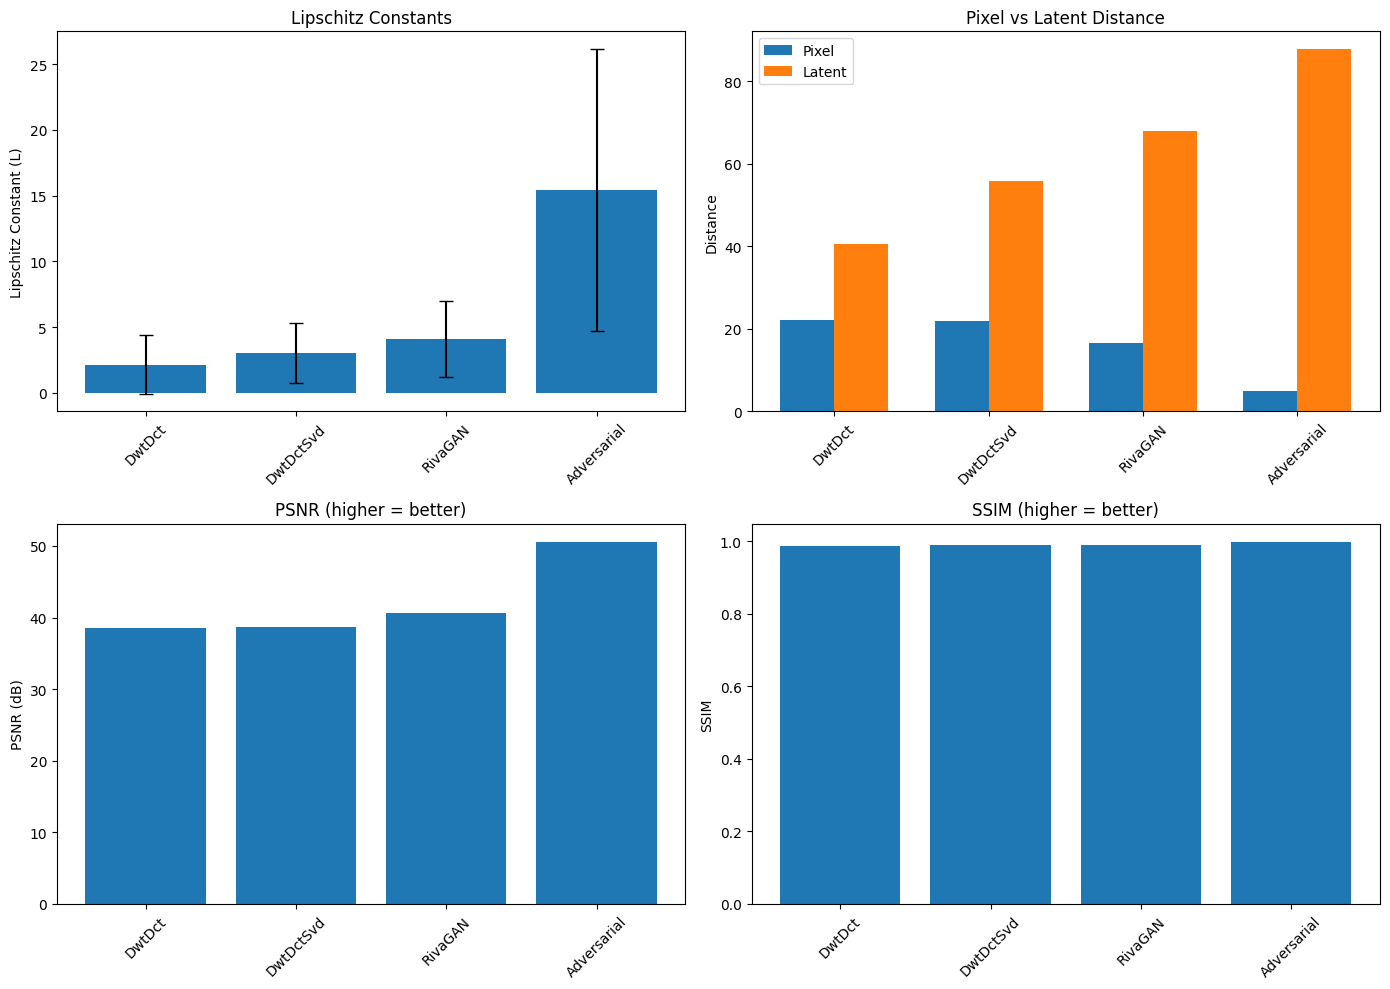

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

methods = list(baseline_results.keys()) + ['Adversarial']
L_means = [baseline_results[k]['L_mean'] for k in baseline_results.keys()] + [adversarial_results['L_mean']]
L_stds = [baseline_results[k]['L_std'] for k in baseline_results.keys()] + [adversarial_results['L_std']]

# Plot 1: Lipschitz (top-left)
axes[0,0].bar(methods, L_means, yerr=L_stds, capsize=5)
axes[0,0].set_ylabel('Lipschitz Constant (L)')
axes[0,0].set_title('Lipschitz Constants')
axes[0,0].tick_params(axis='x', rotation=45)

pixel_means = [baseline_results[k]['pixel_dist_mean'] for k in baseline_results.keys()] + [adversarial_results['pixel_dist_mean']]
latent_means = [baseline_results[k]['latent_dist_mean'] for k in baseline_results.keys()] + [adversarial_results['latent_dist_mean']]

x = np.arange(len(methods))
width = 0.35
# Plot 2: Distances (top-right)
axes[0,1].bar(x - width/2, pixel_means, width, label='Pixel')
axes[0,1].bar(x + width/2, latent_means, width, label='Latent')
axes[0,1].set_ylabel('Distance')
axes[0,1].set_title('Pixel vs Latent Distance')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(methods, rotation=45)
axes[0,1].legend()

# Plot 3: PSNR (bottom-left)
psnr_means = [baseline_results[k]['psnr_mean'] for k in baseline_results.keys()] + [adversarial_results['psnr_mean']]
axes[1,0].bar(methods, psnr_means)
axes[1,0].set_ylabel('PSNR (dB)')
axes[1,0].set_title('PSNR (higher = better)')
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4: SSIM (bottom-right)
ssim_means = [baseline_results[k]['ssim_mean'] for k in baseline_results.keys()] + [adversarial_results['ssim_mean']]
axes[1,1].bar(methods, ssim_means)
axes[1,1].set_ylabel('SSIM')
axes[1,1].set_title('SSIM (higher = better)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'lipschitz_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## Save Results

In [ ]:
import json

results_summary = {
    'baseline': baseline_results,
    'adversarial': adversarial_results,
    'attacked_image_quality': attacked_results,
    'detection_before_attack': {'det_rate': float(det_rate), 'avg_bit_acc': float(avg_bit_acc)},
    'detection_after_regen_vae': {'det_rate': float(attack_det_rate), 'avg_bit_acc': float(attack_avg_bit_acc)},
    'selected_hyperparams': {
        'epsilon_seed_mean_px': float(np.mean([c['eps_seed'] for c in selected_cfgs]) * 255),
        'epsilon_total_mean_px': float(np.mean([c['eps_total'] for c in selected_cfgs]) * 255),
        'lambda_wm_mean': float(np.mean([c['lambda_wm'] for c in selected_cfgs])),
        'technique': 'pairwise_ss_aggressive_highL',
    },
    'violation_ratio': ratio,
    'property_violated': bool(ratio > 3),
    'objective_primary_pre_attack_detectability': bool(det_rate > 0.9),
    'objective_attack_utility_degradation': bool((attacked_results['psnr_mean'] < 30) or (attacked_results['ssim_mean'] < 0.90)),
}
with open(os.path.join(output_dir, 'lipschitz_results.json'), 'w') as f:
    json.dump(results_summary, f, indent=2)
print(f'\nResults saved to {output_dir}')



Results saved to /content/drive/MyDrive/lipschitz_results/
